## Diseñar y entrenar una arquitectura transformar para predecir los valores futuros de una sinusoidal.

In [1]:
import numpy  as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import sys
import os
# Añadir la carpeta src al path
sys.path.append(os.path.abspath("../src"))

from constructor_sinu import sinu_constructed

In [13]:
def set_device ():
    if torch.backends.mps.is_available(): # para usar con mac silicon
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    torch.set_default_device(device)
    print(f"Using {torch.device(device)} device")
    return torch.device(device)

# Define un MLP genérico con cualquier número de capas y activación configurable

from torch import nn

class MLP (nn.Module):
    def __init__(self, arch, activation=nn.Sigmoid): # arch is a list of number of neurons in each layer
        super().__init__()
        self.layers = nn.Sequential()
        for i in range(1,len(arch)):
            self.layers.add_module(f"Linear {i}", nn.Linear(arch[i-1], arch[i]))
            if i != len(arch)-1:
                self.layers.add_module(f"Activation {i}", activation())

    def forward(self, x):
        logits = self.layers(x)
        return logits

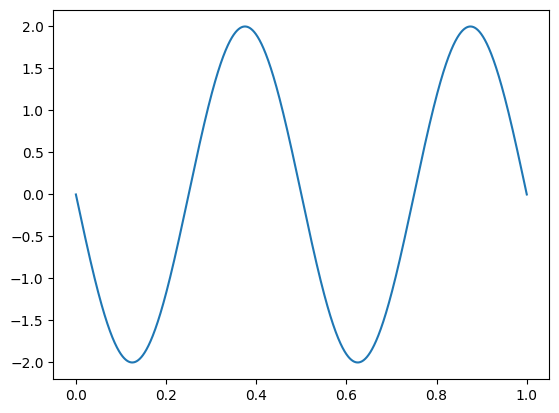

In [29]:
# contruimos sinusoide 
x,y = sinu_constructed(0,1,2000,2,4*np.pi,-np.pi)
plt.plot(x,y)

In [30]:
# convertir tensores numpy a pytorch: torch.from_numpy()
# convertir datos torch a numpy: X.cpu().numpy()
# enviar datos a la GPU: X.to(device)

device = set_device()

X = torch.from_numpy(x) # convierte a torch
Y = torch.from_numpy(y)

print(Y)
Y.device

Y = Y.to(device) # envía a GPU
print(Y.device)

Using cuda device
tensor([-2.4493e-16, -1.2573e-02, -2.5145e-02,  ...,  2.5145e-02,
         1.2573e-02,  7.3479e-16], dtype=torch.float64)
cuda:0


In [31]:
# redimensiona X para que los ejemplos estén en la primera dimensión

X = X.view((-1,1))
X.shape

Y = Y.view((-1,1))
Y.shape

torch.Size([2000, 1])

In [32]:
# train y test genéricos con nuestro propio TesorLoader

class TensorLoader: # class to get batches from tensors X, Y; much more efficient than DataLoader
    def __init__ (self, X, Y, bs=None):
        self.X = X
        self.Y = Y
        self.p0 = 0
        self.len = len(X)
        self.bs = bs if bs else self.len
        self.nbatch = self.len // self.bs
        if self.len % self.bs != 0: self.nbatch += 1 # para range de bucles for
        self.ite = 0

    def next (self):
        pf = self.p0 + self.bs
        if pf > self.len: pf = self.len
        resX = self.X[self.p0:pf,:]
        resY = self.Y[self.p0:pf,:]
        self.p0 += self.bs
        self.ite += 1
        if self.p0 >= self.len: 
            self.p0 = self.ite = 0
        return resX, resY
    
def train (X, Y, model, loss_fn, optimizer, epochs=1000, bs=None, device='cpu', trace=100): # train con batches usando TensorLoader
    dataloader = TensorLoader(X, Y, bs=bs) 
    model = model.to(device)
    model.train() # indica que estamos entrenando (para capas Dropout y BatchNorm), el opuesto es model.eval
    for e in range(epochs):
        optimizer.zero_grad() # reset gradients
        acum_loss = 0
        for _ in range(dataloader.nbatch): # para cada batch
            X, Y = dataloader.next()
            X, Y = X.to(device,dtype=torch.float32), Y.to(device,dtype=torch.float32)
            pred = model(X) # propagate
            loss = loss_fn(pred, Y) # prediction error
            acum_loss += loss.item()
            loss.backward() # back propagation
            optimizer.step() # update parameters

        if (e+1) % trace == 0: # traces
            print(f"loss: {acum_loss/dataloader.nbatch:>7f} [{(e+1):>5d} /{epochs:>5d}]")

def test (X, Y, model, metric_list, bs=None, device='cpu'): # test con batches usando TensorLoader
    dataloader = TensorLoader(X, Y, bs=bs) 
    model = model.to(device)
    model.eval() # indica que estamos evaluando (para capas Dropout y BatchNorm)
    acum = np.zeros(len(metric_list))
    for _ in range(dataloader.nbatch): # para cada batch
        X, Y = dataloader.next()
        X, Y = X.to(device,dtype=torch.float32), Y.to(device,dtype=torch.float32)
        pred = model(X) # propagate
        for i,m in enumerate(metric_list):
            v = m(pred,Y).item()
            acum[i] += v

    acum /= dataloader.nbatch
    [print(f"{x:.6f}", end='; ') for x in acum]
    return acum

In [33]:
# modelo para aprender la función seno

#model = basic_MLP(1, 500, 1)
model = MLP([1, 50, 50, 50, 1], activation=nn.ReLU)
print(model)

# # acceso a parámetros del modelo
# with torch.no_grad(): # para modificar pesos (útil en neuroevolución)
#     model.layers[0].weight[0,0] = 0.0
# print(model.layers[0].weight)
# print(model.layers[0].weight.shape)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

MLP(
  (layers): Sequential(
    (Linear 1): Linear(in_features=1, out_features=50, bias=True)
    (Activation 1): ReLU()
    (Linear 2): Linear(in_features=50, out_features=50, bias=True)
    (Activation 2): ReLU()
    (Linear 3): Linear(in_features=50, out_features=50, bias=True)
    (Activation 3): ReLU()
    (Linear 4): Linear(in_features=50, out_features=1, bias=True)
  )
)


In [37]:
%time train(X, Y, model, loss_fn, optimizer, 2000, device=device, trace=100)

loss: 0.001058 [  100 / 2000]
loss: 0.001016 [  200 / 2000]
loss: 0.000992 [  300 / 2000]
loss: 0.000958 [  400 / 2000]
loss: 0.000932 [  500 / 2000]
loss: 0.000886 [  600 / 2000]
loss: 0.001067 [  700 / 2000]
loss: 0.002796 [  800 / 2000]
loss: 0.000808 [  900 / 2000]
loss: 0.000774 [ 1000 / 2000]
loss: 0.000750 [ 1100 / 2000]
loss: 0.000750 [ 1200 / 2000]
loss: 0.000704 [ 1300 / 2000]
loss: 0.001748 [ 1400 / 2000]
loss: 0.000661 [ 1500 / 2000]
loss: 0.000638 [ 1600 / 2000]
loss: 0.000726 [ 1700 / 2000]
loss: 0.000600 [ 1800 / 2000]
loss: 0.000582 [ 1900 / 2000]
loss: 0.003040 [ 2000 / 2000]
CPU times: user 5.44 s, sys: 1.38 s, total: 6.82 s
Wall time: 6.88 s


In [38]:
# define algunas métricas útiles

def r2_loss(output, target): # coeficiente de determinación
    target_mean = torch.mean(target)
    ss_tot = torch.sum((target - target_mean) ** 2)
    ss_res = torch.sum((target - output) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2

def binary_accuracy (output, target): # para una única salida o salidas independientes
    bin_out = (output > 0.5).float()
    return 1 - torch.abs(bin_out-target).mean()

def accuracy (output, target): # para salidas excluyentes (predicción de clase)
    return (torch.argmax(output, dim=1)==torch.argmax(target, dim=1)).float().mean()

test(X, Y, model, [torch.nn.MSELoss(), torch.nn.L1Loss(), r2_loss, binary_accuracy, accuracy])

0.003854; 0.057555; 0.998072; 0.103293; 1.000000; 

array([0.00385447, 0.05755468, 0.99807179, 0.10329258, 1.        ])

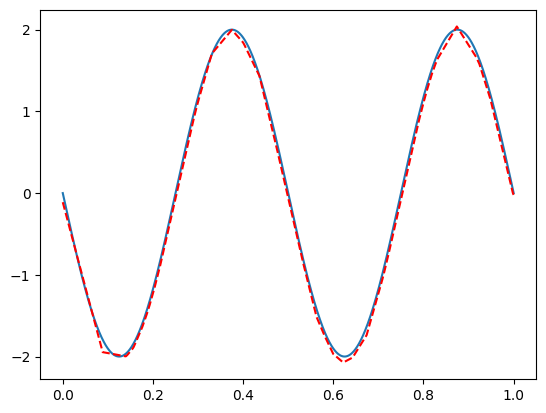

In [39]:
# plot model outputs

%matplotlib inline

import matplotlib.pyplot as plt

model.to(device)
y_pred = model(X.to(device,dtype=torch.float32))

yp = y_pred.detach().cpu().numpy()

plt.plot(x,y)
plt.plot(x,yp,'r--')